<a href="https://colab.research.google.com/github/Annaa74/Google-colab-models/blob/main/CNN(2)_CIAFR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers , models
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [ ]:
(X_train, Y_train), (X_test, Y_test) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
print("Training data shape" , X_train.shape)
print("Test data shape" , X_test.shape )

Training data shape (50000, 32, 32, 3)
Test data shape (10000, 32, 32, 3)


In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

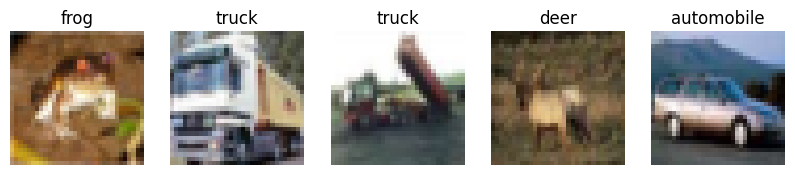

In [ ]:
plt.figure(figsize=(10,2))
for i in range(5):
  plt.subplot(1,5,i+1)
  plt.imshow(X_train[i], cmap='gray')
  plt.title(class_names[Y_train[i][0]])
  plt.axis('off')
plt.show()

In [ ]:
X_train = X_train / 255.0
X_test =X_test / 255.0

In [ ]:
X_train = X_train.reshape(-1,32,32,3)
X_test = X_test.reshape(-1,32,32,3)

In [ ]:
Y_train_cat = to_categorical(Y_train,10)
Y_test_cat = to_categorical(Y_test,10)

In [ ]:
X_train,X_val,Y_train_cat, y_val_cat = train_test_split(X_train,Y_train_cat,test_size=0.2,random_state=42)

In [ ]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(X_train, Y_train_cat, epochs=10, validation_data=(X_val, y_val_cat))

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 59s 46ms/step - accuracy: 0.3171 - loss: 1.8396 - val_accuracy: 0.5402 - val_loss: 1.2953
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 51s 41ms/step - accuracy: 0.5512 - loss: 1.2660 - val_accuracy: 0.5943 - val_loss: 1.1440
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 53s 42ms/step - accuracy: 0.6086 - loss: 1.0968 - val_accuracy: 0.6345 - val_loss: 1.0367
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 80s 41ms/step - accuracy: 0.6571 - loss: 0.9750 - val_accuracy: 0.6575 - val_loss: 0.9786
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - accuracy: 0.6886 - loss: 0.8849 - val_accuracy: 0.6676 - val_loss: 0.9588
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 51s 41ms/step - accuracy: 0.7047 - loss: 0.8414 - val_accuracy: 0.6757 - val_loss: 0.9433
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 51s 41ms/step - accuracy: 0.7270 - loss: 0.7773 - val_accuracy: 0.6889 - val_loss: 0.9094
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 84s 42ms/step - accuracy: 0.7489 -

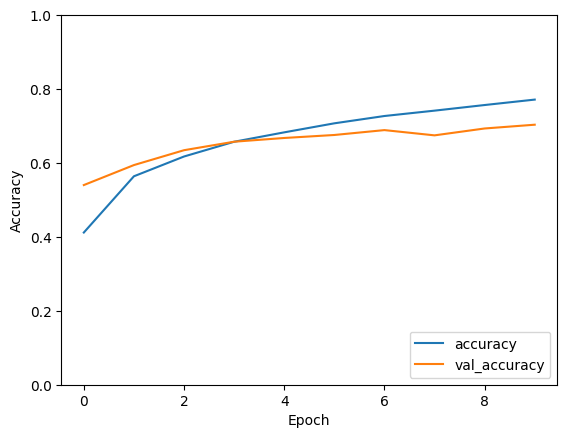

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()